In [ ]:
!pip install torch torchvision matplotlib numpy tqdm


In [ ]:
import torch, random, numpy as np

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()   # ONLY [0,1]
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = DataLoader(testset, batch_size=128, shuffle=False)

classes = trainset.classes


100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


['frog', 'airplane', 'deer', 'automobile', 'bird', 'horse', 'truck', 'deer']


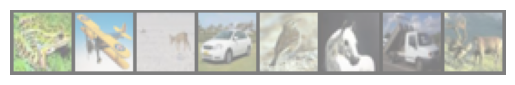

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print([classes[l] for l in labels[:8]])


Model Define

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training


In [ ]:
def train(model, epochs=10):
    model.train()
    for epoch in range(epochs):
        correct, total, loss_sum = 0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss_sum:.3f} | Acc: {acc:.2f}%")
train(model, epochs=10)


Epoch [1/10] | Loss: 581.847 | Acc: 46.64%
Epoch [2/10] | Loss: 438.110 | Acc: 60.54%
Epoch [3/10] | Loss: 377.957 | Acc: 66.12%
Epoch [4/10] | Loss: 335.115 | Acc: 69.93%
Epoch [5/10] | Loss: 300.565 | Acc: 72.92%
Epoch [6/10] | Loss: 267.753 | Acc: 76.12%
Epoch [7/10] | Loss: 241.518 | Acc: 78.43%
Epoch [8/10] | Loss: 209.743 | Acc: 81.34%
Epoch [9/10] | Loss: 179.908 | Acc: 83.99%
Epoch [10/10] | Loss: 150.447 | Acc: 86.86%


Test Accuracy


In [ ]:
def test_accuracy(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100 * correct / total
print("Clean Test Accuracy:", test_accuracy(model))


Clean Test Accuracy: 71.57


FGSM

In [ ]:
def fgsm_attack(model, images, labels, epsilon=0.03):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    images.requires_grad = True

    outputs = model(images)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    adv = images + epsilon * images.grad.sign()
    return torch.clamp(adv, 0, 1).detach()


PGD

In [ ]:
def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.007, iters=10):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    ori = images.clone().detach()

    for _ in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv = images + alpha * images.grad.sign()
        eta = torch.clamp(adv - ori, -epsilon, epsilon)
        images = torch.clamp(ori + eta, 0, 1).detach()

    return images


CONFIDENCE-BASED DETECTOR

In [ ]:
def detect_adversarial(outputs, threshold=0.7):
    probs = torch.softmax(outputs, dim=1)
    confidence, _ = probs.max(1)
    return confidence < threshold


SAFE PREDICTION

In [ ]:
def safe_predict(model, images):
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    conf, preds = probs.max(1)
    preds[conf < 0.7] = -1
    return preds


SINGLE IMAGE TEST

In [ ]:
model.eval()

dataiter = iter(testloader)
images, labels = next(dataiter)

image = images[0:1].to(device)
label = labels[0:1].to(device)

# Clean
out_clean = model(image)
conf_clean = torch.softmax(out_clean, dim=1).max().item()

# PGD
adv_pgd = pgd_attack(model, image, label)
out_pgd = model(adv_pgd)
conf_pgd = torch.softmax(out_pgd, dim=1).max().item()

print("Clean confidence:", round(conf_clean, 3))
print("PGD confidence:", round(conf_pgd, 3))
print("Detected (confidence-based):", detect_adversarial(out_pgd).item())
print("Safe prediction:", safe_predict(model, adv_pgd).item())


Clean confidence: 0.56
PGD confidence: 0.587
Detected (confidence-based): True
Safe prediction: -1


Batch Accuracy Evaluation

In [ ]:
def evaluate_accuracy(model, loader, attack=None, defense=False):
    model.eval()
    correct, total, rejected = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Apply attack
        if attack == "fgsm":
            images = fgsm_attack(model, images, labels)
        elif attack == "pgd":
            images = pgd_attack(model, images, labels)

        # Predict
        outputs = model(images)

        if defense:
            preds = safe_predict(model, images)
            rejected += (preds == -1).sum().item()
            valid = preds != -1
            correct += (preds[valid] == labels[valid]).sum().item()
            total += valid.sum().item()
        else:
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / max(total, 1)
    return acc, rejected


Run Final Experiments

In [ ]:
results = {}

results["Clean"] = evaluate_accuracy(model, testloader)
results["FGSM"] = evaluate_accuracy(model, testloader, attack="fgsm")
results["PGD"]  = evaluate_accuracy(model, testloader, attack="pgd")

results["FGSM + Defense"] = evaluate_accuracy(
    model, testloader, attack="fgsm", defense=True
)
results["PGD + Defense"] = evaluate_accuracy(
    model, testloader, attack="pgd", defense=True
)

for k, v in results.items():
    print(f"{k:15s} -> Accuracy: {v[0]:.2f}% | Rejected: {v[1]}")


Clean           -> Accuracy: 71.57% | Rejected: 0
FGSM            -> Accuracy: 1.35% | Rejected: 0
PGD             -> Accuracy: 0.10% | Rejected: 0
FGSM + Defense  -> Accuracy: 0.72% | Rejected: 1643
PGD + Defense   -> Accuracy: 0.04% | Rejected: 118


Detection Metrics

In [ ]:
def evaluate_detection_metrics(model, loader, attack="pgd", threshold=0.7):
    TP = FP = TN = FN = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Clean
        outputs = model(images)
        detected = detect_adversarial(outputs, threshold)
        FP += detected.sum().item()
        TN += (~detected).sum().item()

        # Adversarial
        if attack == "fgsm":
            adv = fgsm_attack(model, images, labels)
        else:
            adv = pgd_attack(model, images, labels)

        outputs_adv = model(adv)
        detected_adv = detect_adversarial(outputs_adv, threshold)
        TP += detected_adv.sum().item()
        FN += (~detected_adv).sum().item()

    return {
        "TP": TP, "FP": FP,
        "FN": FN, "TN": TN,
        "Detection Acc": (TP + TN) / (TP + TN + FP + FN)
    }

print("PGD Detection Metrics:")
print(evaluate_detection_metrics(model, testloader, attack="pgd"))


PGD Detection Metrics:
{'TP': 118, 'FP': 2851, 'FN': 9882, 'TN': 7149, 'Detection Acc': 0.36335}


latency


In [ ]:
import time

image, _ = next(iter(testloader))
image = image.to(device)

start = time.time()
_ = safe_predict(model, image)
end = time.time()

print("Inference latency (ms):", (end - start) * 1000)


Inference latency (ms): 0.9706020355224609


Why this step because the simple cnn model is traineedd
and fgsm attack is applied in the image and then the accuracy drops it leads to the mis classifiction  ,,the detection fails because the confidence score and the reconstruction error is very low it is caused by the fgsm error  so we are training the model with the adversial examples(Model hardening)

After adversial training




In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

classes = trainset.classes

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def fgsm_attack(model, images, labels, epsilon):
    images.requires_grad = True
    outputs = model(images)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    perturbed = images + epsilon * images.grad.sign()
    return torch.clamp(perturbed, 0, 1).detach()

epsilon = 0.03
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        # Generate adversarial images
        adv_images = fgsm_attack(model, images, labels, epsilon)

        # Combine clean + adversarial
        all_images = torch.cat([images, adv_images], dim=0)
        all_labels = torch.cat([labels, labels], dim=0)

        optimizer.zero_grad()
        outputs = model(all_images)
        loss = criterion(outputs, all_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {running_loss/len(trainloader):.4f}")


def evaluate(model, loader, attack=False):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if attack:
            images = fgsm_attack(model, images, labels, epsilon)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return 100 * correct / total


clean_acc = evaluate(model, testloader, attack=False)
adv_acc = evaluate(model, testloader, attack=True)

print("\nClean Accuracy after Adversarial Training:", clean_acc)
print("Adversarial Accuracy after Adversarial Training:", adv_acc)


KeyboardInterrupt: 

Stability Detector Function

In [ ]:
def stability_score(model, image, runs=5, noise_std=0.01):
    model.eval()
    probs = []

    for _ in range(runs):
        noisy = image + noise_std * torch.randn_like(image)
        noisy = torch.clamp(noisy, 0, 1)

        out = model(noisy)
        probs.append(torch.softmax(out, dim=1))

    probs = torch.stack(probs)   # [runs, 1, num_classes]
    return probs.var(dim=0).mean().item()


Hybrid Detection Logic

In [ ]:
def hybrid_detect(model, image, conf_thresh=0.7, stab_thresh=0.005):
    outputs = model(image)
    probs = torch.softmax(outputs, dim=1)
    confidence = probs.max().item()

    stab = stability_score(model, image)

    if confidence < conf_thresh or stab > stab_thresh:
        return True   # adversarial
    return False
